# Notebook 02 - Exploratory Data Analysis & Statistical Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")

In [3]:
Data_Path = Path("C:/Users/Lenovo/OneDrive/Bureau/Data_portofoliu/Proiect2/telecom-churn-analysis/data/cleaned_analysis_df.csv")

In [4]:
df = pd.read_csv(Data_Path)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")

Rows: 6,589
Columns: 44


In [5]:
#Analytical population
print(f"Analytical population: {len(df):,} rows")

Analytical population: 6,589 rows


In [6]:
df["Customer Status"].value_counts()

Customer Status
Stayed     4720
Churned    1869
Name: count, dtype: int64

Churn flag verification

In [7]:
pd.crosstab(df["Customer Status"], df["Churn Flag"])

Churn Flag,0,1
Customer Status,,
Churned,0,1869
Stayed,4720,0


### Overall Churn Overview

What proportion of customers are churning?

In [8]:
churn_summary = df["Customer Status"].value_counts().to_frame("customers")

churn_summary["percentage"] = churn_summary["customers"] / churn_summary["customers"].sum() * 100

churn_summary

,customers,percentage
Customer Status,,
Stayed,4720,71.63
Churned,1869,28.37


Churn rate

In [9]:
churn_rate = df["Churn Flag"].mean() * 100
print(f"Churn rate: {churn_rate:.2f}%")

Churn rate: 28.37%


Visual churn distribution

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13412\3304306444.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Customer Status", data=df, palette="Set2")


Text(0.5, 1.0, 'Customer Status Distribution')

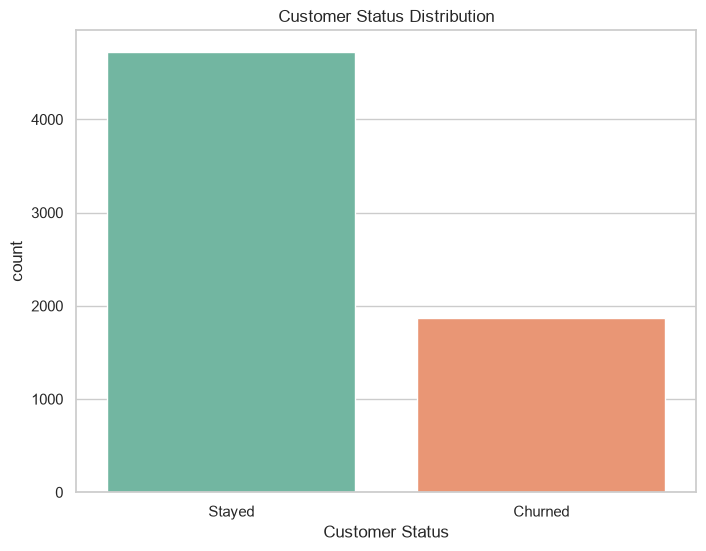

In [10]:
plt.figure(figsize=(8, 6))

sns.countplot(x="Customer Status", data=df, palette="Set2")
plt.title("Customer Status Distribution")

### Demographic analysis

Are younger or older customers more likely to churn?

In [11]:
age_by_status = (df.groupby("Customer Status")["Age"].agg(["count", "mean", "median", "std"]))

age_by_status

,count,mean,median,std
Customer Status,,,,
Churned,1869,49.74,50.00,17.60
Stayed,4720,45.58,45.00,16.38


Age distribution by churn status

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13412\3098319694.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Customer Status", y="Age", data=df, palette="Set2")


Text(0.5, 1.0, 'Age Distribution by Customer Status')

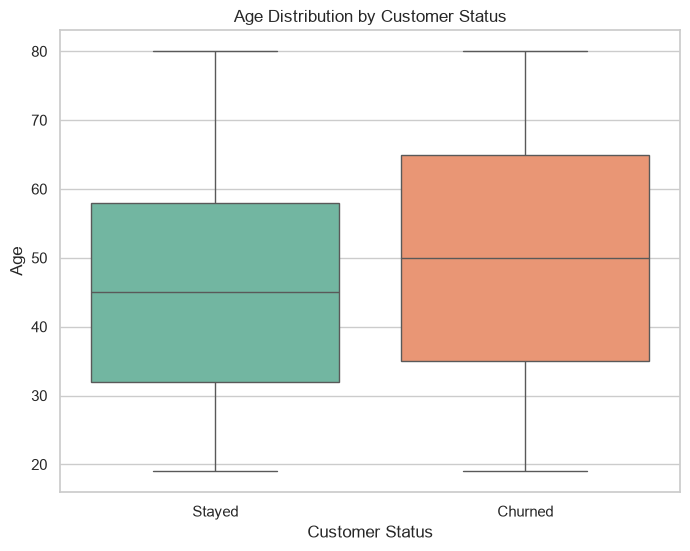

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="Customer Status", y="Age", data=df, palette="Set2")
plt.title("Age Distribution by Customer Status")

In [13]:
age_churn = df.groupby("Age Segment")["Churn Flag"].agg(["count", "mean", "sum"])

age_churn["churn_rate"] = age_churn["mean"] * 100

age_churn.sort_values(by="churn_rate", ascending=False)

,count,mean,sum,churn_rate
Age Segment,,,,
65+,1034,0.43,445,43.04
46-55,1198,0.27,325,27.13
26-35,1155,0.26,302,26.15
56-65,1151,0.26,300,26.06
36-45,1200,0.26,307,25.58
18-25,851,0.22,190,22.33


### Visual distribution of churn by age segment

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13412\4206605626.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_churn.index, y=age_churn["churn_rate"], palette="Set2")


Text(0, 0.5, 'Churn Rate (%)')

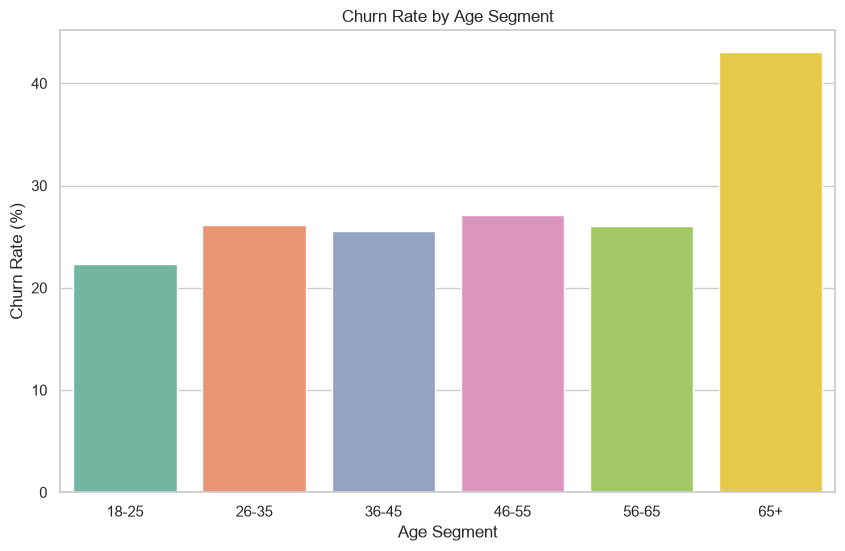

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(x=age_churn.index, y=age_churn["churn_rate"], palette="Set2")
plt.title("Churn Rate by Age Segment")
plt.xlabel("Age Segment")
plt.ylabel("Churn Rate (%)")

### Gender Analysis

Does churn differ between male and female customers?

In [15]:
gender_churn = df.groupby("Gender")["Churn Flag"].agg(["count", "mean", "sum"])

gender_churn["churn_rate"] = gender_churn["mean"] * 100
gender_churn.sort_values(by="churn_rate", ascending=False)

,count,mean,sum,churn_rate
Gender,,,,
Female,3277,0.29,939,28.65
Male,3312,0.28,930,28.08


Visual distribution

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13412\3899428925.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_churn.index, y=gender_churn["churn_rate"], palette="Set2")


Text(0, 0.5, 'Churn Rate (%)')

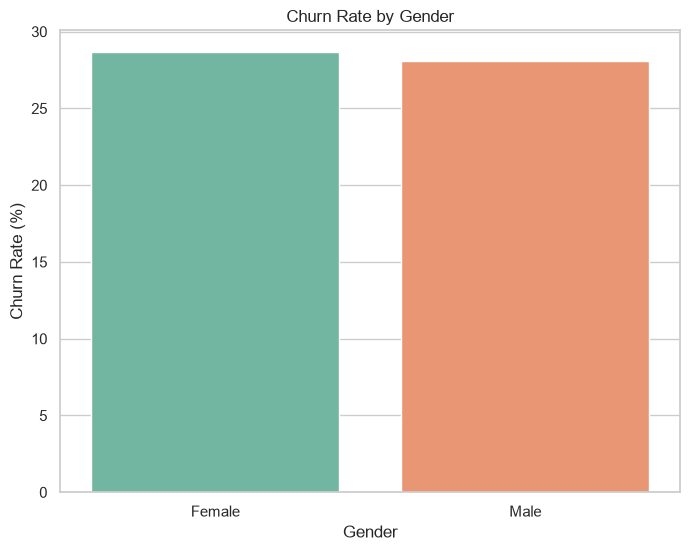

In [16]:
plt.figure(figsize=(8, 6))

sns.barplot(x=gender_churn.index, y=gender_churn["churn_rate"], palette="Set2")
plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

### Marriage and dependents

Does household status relate to churn?

In [17]:
marital_churn = df.groupby("Married")["Churn Flag"].agg(
        customers="count",
        churned_customers="sum",
        churn_rate="mean"
)
marital_churn["churn_rate"] = marital_churn["churn_rate"] * 100

marital_churn

,customers,churned_customers,churn_rate
Married,,,
No,3271,1200,36.69
Yes,3318,669,20.16


In [18]:
df["Dependents Segment"] = pd.cut(
    df["Number of Dependents"],
    bins=[-1, 0, 3, np.inf],
    labels=["None", "1-3", "4+"]
)

In [19]:
dependents_churn = (
    df
    .groupby("Dependents Segment", observed=True)["Churn Flag"]
    .agg(
        customers="count",
        churned_customers="sum",
        churn_rate="mean"
    )
)

dependents_churn["churn_rate"] *= 100

dependents_churn

,customers,churned_customers,churn_rate
Dependents Segment,,,
None,5042,1763,34.97
1-3,1523,101,6.63
4+,24,5,20.83


### Customer lifecycle - tenure

Are new customers more likely to churn?

In [20]:
tenure_by_status = (
    df
    .groupby("Customer Status")["Tenure in Months"]
    .agg(["count", "mean", "median", "std"])
)

tenure_by_status

,count,mean,median,std
Customer Status,,,,
Churned,1869,17.98,10.00,19.53
Stayed,4720,41.04,42.00,22.36


Tenure distribution

Text(0, 0.5, 'Tenure (Months)')

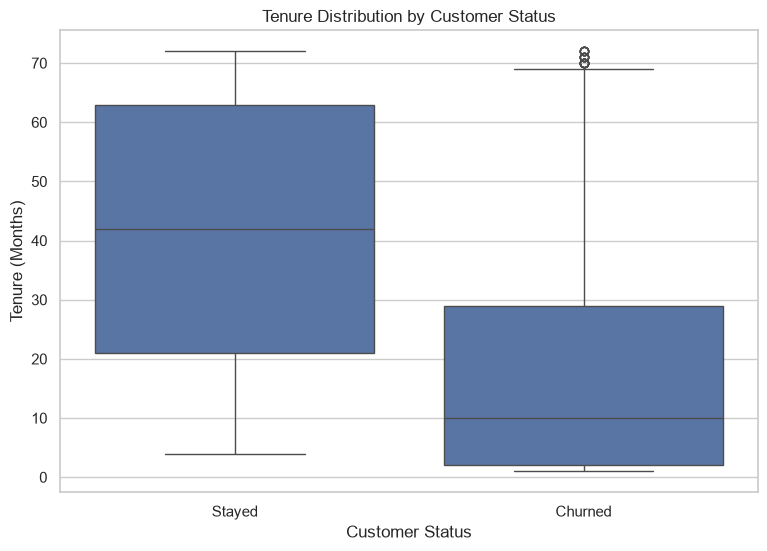

In [21]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Customer Status",
    y="Tenure in Months"
)

plt.title("Tenure Distribution by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Tenure (Months)")

Churn by tenure segment

In [22]:
tenure_churn = (
    df
    .groupby("Tenure Segment", observed=True)["Churn Flag"]
    .agg(
        customers="count",
        churned_customers="sum",
        churn_rate="mean"
    )
)

tenure_churn["churn_rate"] *= 100

tenure_churn

,customers,churned_customers,churn_rate
Tenure Segment,,,
0-6 months,1016,784,77.17
13-24 months,1024,294,28.71
25-48 months,1594,325,20.39
49+ months,2239,213,9.51
7-12 months,716,253,35.34


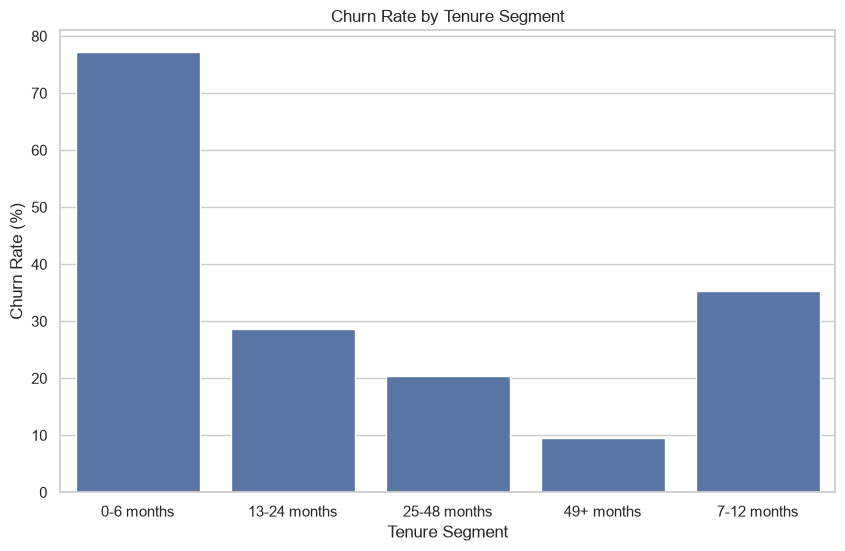

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=tenure_churn.reset_index(),
    x="Tenure Segment",
    y="churn_rate"
)

plt.title("Churn Rate by Tenure Segment")
plt.xlabel("Tenure Segment")
plt.ylabel("Churn Rate (%)")

plt.show()

### Number of referrals

Are customers with more refferals less likely to churn?

In [24]:
referral_churn = (
    df
    .groupby("Number of Referrals")["Churn Flag"]
    .agg(
        customers="count",
        churned_customers="sum",
        churn_rate="mean"
    )
)

referral_churn["churn_rate"] *= 100

referral_churn

,customers,churned_customers,churn_rate
Number of Referrals,,,
0,3448,1245,36.11
1,1071,507,47.34
2,229,26,11.35
3,247,32,12.96
4,233,18,7.73
5,255,21,8.24
6,214,8,3.74
7,243,6,2.47
8,206,2,0.97


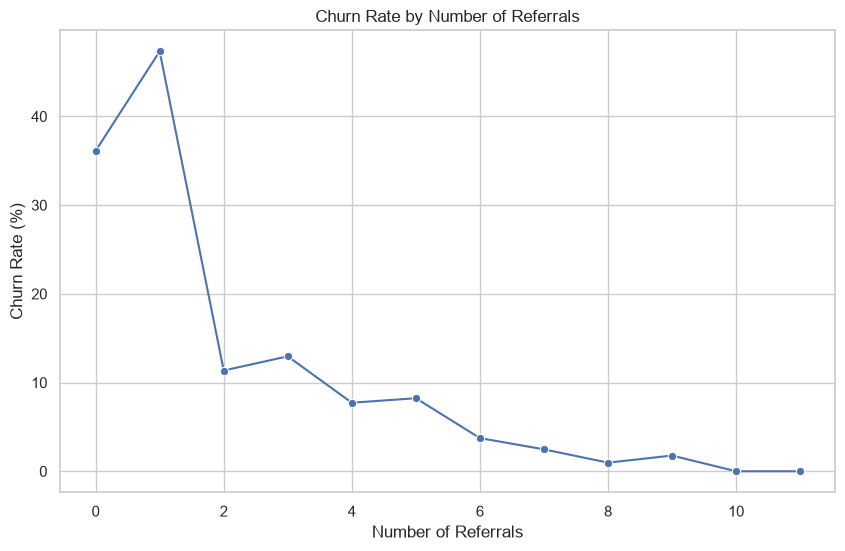

In [25]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=referral_churn.reset_index(),
    x="Number of Referrals",
    y="churn_rate",
    marker="o"
)

plt.title("Churn Rate by Number of Referrals")
plt.xlabel("Number of Referrals")
plt.ylabel("Churn Rate (%)")

plt.show()

### Contract analysis

Wich contract type has the highest churn?

In [26]:
contract_churn = (
    df
    .groupby("Contract")["Churn Flag"]
    .agg(
        customers="count",
        churned_customers="sum",
        churn_rate="mean"
    )
)

contract_churn["churn_rate"] *= 100

contract_churn.sort_values(
    "churn_rate",
    ascending=False
)

,customers,churned_customers,churn_rate
Contract,,,
Month-to-Month,3202,1655,51.69
One Year,1526,166,10.88
Two Year,1861,48,2.58


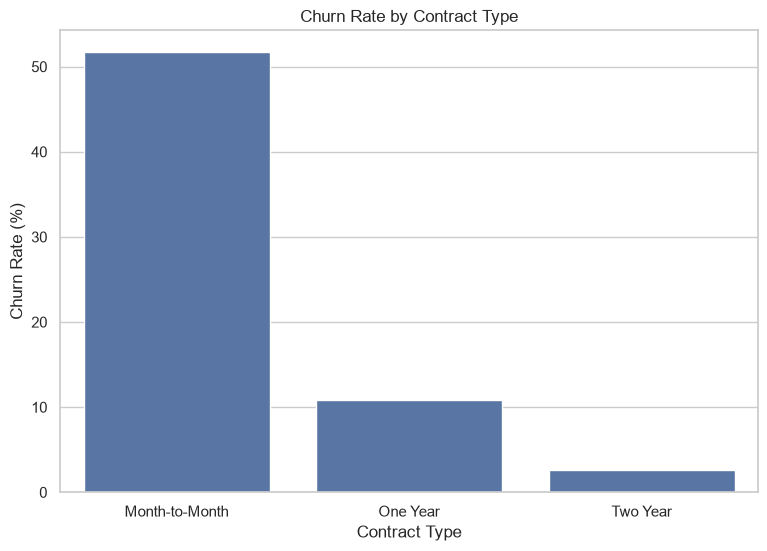

In [27]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=contract_churn.reset_index(),
    x="Contract",
    y="churn_rate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

### Offer analysis

In [28]:
offer_churn = (
    df
    .groupby("Offer")["Churn Flag"]
    .agg(
        customers="count",
        churned_customers="sum",
        churn_rate="mean"
    )
)

offer_churn["churn_rate"] *= 100

offer_churn.sort_values(
    "churn_rate",
    ascending=False
)

,customers,churned_customers,churn_rate
Offer,,,
Offer E,630,426,67.62
Offer D,602,161,26.74
Offer C,415,95,22.89
Offer B,824,101,12.26
Offer A,520,35,6.73


Why does Offer E have such a high churn rate?

In [40]:
offer_contract = pd.crosstab(
    df["Offer"],
    df["Contract"],
    normalize="index"
).round(4) * 100

offer_contract

Contract,Month-to-Month,One Year,Two Year
Offer,,,
Offer A,2.88,18.65,78.46
Offer B,26.21,38.47,35.32
Offer C,48.92,34.46,16.63
Offer D,72.09,18.44,9.47
Offer E,89.84,5.24,4.92


In [43]:
offer_tenure = (
    df
    .groupby("Offer", observed=True)
    .agg(
        customers=("Customer ID", "count"),
        avg_tenure=("Tenure in Months", "mean"),
        median_tenure=("Tenure in Months", "median"),
        avg_monthly_charges=("Monthly Charge", "mean"),
        churn_rate=("Churn Flag", "mean")
))

offer_tenure["churn_rate"] *= 100
offer_tenure.round(2)

,customers,avg_tenure,median_tenure,avg_monthly_charges,churn_rate
Offer,,,,,
Offer A,520,70.00,71.00,77.82,6.73
Offer B,824,53.36,54.00,70.82,12.26
Offer C,415,30.76,30.00,66.83,22.89
Offer D,602,15.95,16.00,58.21,26.74
Offer E,630,4.26,4.00,59.26,67.62


In [44]:
offer_internet = pd.crosstab(
    df["Offer"],
    df["Internet Service"],
    normalize="index"
).round(4) * 100

offer_internet

Internet Service,No,Yes
Offer,,
Offer A,17.69,82.31
Offer B,19.66,80.34
Offer C,19.52,80.48
Offer D,27.41,72.59
Offer E,18.10,81.90


### Internet service

Does the type of internet service relate to churn?

In [30]:
internet_service_churn = (
    df
    .groupby("Internet Service")["Churn Flag"]
    .agg(
        customers="count",
        churned_customers="sum",
        churn_rate="mean"
    )
)

internet_service_churn["churn_rate"] *= 100

internet_service_churn

,customers,churned_customers,churn_rate
Internet Service,,,
No,1344,113,8.41
Yes,5245,1756,33.48


### Internet type

In [31]:
internet_type_churn = (
    df
    .groupby("Internet Type")["Churn Flag"]
    .agg(
        customers="count",
        churned_customers="sum",
        churn_rate="mean"
    )
)

internet_type_churn["churn_rate"] *= 100

internet_type_churn.sort_values(
    "churn_rate",
    ascending=False
)

,customers,churned_customers,churn_rate
Internet Type,,,
Fiber Optic,2934,1236,42.13
Cable,774,213,27.52
DSL,1537,307,19.97


Text(0, 0.5, 'Churn Rate (%)')

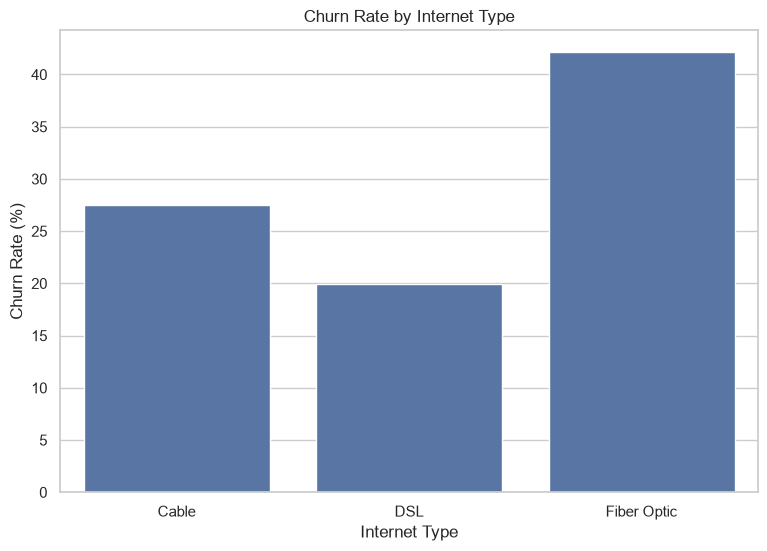

In [32]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=internet_type_churn.reset_index(),
    x="Internet Type",
    y="churn_rate"
)

plt.title("Churn Rate by Internet Type")
plt.xlabel("Internet Type")
plt.ylabel("Churn Rate (%)")

In [ ]:
fiber_optic_churn = (
        df
    .groupby("Internet Type", observed=True)
    .agg(
        customers=("Customer ID", "count"),
        avg_tenure=("Tenure in Months", "mean"),
        median_tenure=("Tenure in Months", "median"),
        avg_monthly_charges=("Monthly Charge", "mean"),
        churn_rate=("Churn Flag", "mean")
))

fiber_optic_churn["churn_rate"] *= 100
fiber_optic_churn.round(2)

,customers,avg_tenure,median_tenure,avg_monthly_charges,churn_rate
Internet Type,,,,,
Cable,774,34.16,31.50,61.13,27.52
DSL,1537,35.21,33.00,59.06,19.97
Fiber Optic,2934,34.21,32.00,91.99,42.13


### Services analysis

In [36]:
service_columns = [
    "Online Security",
    "Online Backup",
    "Device Protection Plan",
    "Premium Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Streaming Music"
]

In [39]:
service_results = []

for column in service_columns:
    temp = (
        df
        .groupby(column)["Churn Flag"]
        .agg(
            customers="count",
            churned_customers="sum",
            churn_rate="mean"
        )
    )

    temp["churn_rate"] *= 100
    temp["service"] = column

    service_results.append(temp)

service_churn = pd.concat(service_results).reset_index()

service_churn.sort_values(
    "churn_rate",
    ascending=False
)

,index,customers,churned_customers,churn_rate,service
0,No,3272,1461,44.65,Online Security
6,No,3248,1446,44.52,Premium Tech Support
2,No,2870,1233,42.96,Online Backup
4,No,2855,1211,42.42,Device Protection Plan
10,No,2562,938,36.61,Streaming Movies
12,No,2809,1028,36.60,Streaming Music
8,No,2587,942,36.41,Streaming TV
9,Yes,2658,814,30.62,Streaming TV
11,Yes,2683,818,30.49,Streaming Movies
13,Yes,2436,728,29.89,Streaming Music


### Financial and Revenue analysis

In [49]:
financial_cols = [
    "Monthly Charge",
    "Total Charges",
    "Total Refunds",
    "Total Extra Data Charges",
    "Total Long Distance Charges",
    "Total Revenue"
]

df[financial_cols].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Monthly Charge,6475.00,66.27,29.92,18.25,40.58,72.90,90.60,118.75
Total Charges,6589.00,2432.04,2265.50,18.85,544.55,1563.90,4003.00,8684.80
Total Refunds,6589.00,2.08,8.13,0.00,0.00,0.00,0.00,49.79
Total Extra Data Charges,6589.00,7.17,25.80,0.00,0.00,0.00,0.00,150.00
Total Long Distance Charges,6589.00,798.09,853.77,0.00,106.68,472.68,1275.12,3564.72
Total Revenue,6589.00,3235.22,2854.60,21.61,835.45,2376.45,5106.64,11979.34


### Financial metrics by customer status

Do churned customers generate different revenue than retained customers?

In [50]:
financial_by_status = (
    df.groupby("Customer Status")
    .agg(
        customers=("Customer ID", "count"),
        avg_monthly_charge=("Monthly Charge", "mean"),
        median_monthly_charge=("Monthly Charge", "median"),
        avg_total_charges=("Total Charges", "mean"),
        avg_total_refunds=("Total Refunds", "mean"),
        avg_total_extra_data_charges=("Total Extra Data Charges", "mean"),
        avg_total_long_distance_charges=("Total Long Distance Charges", "mean"),
        total_revenue=("Total Revenue", "sum")
    ).round(2)
)

financial_by_status

,customers,avg_monthly_charge,median_monthly_charge,avg_total_charges,avg_total_refunds,avg_total_extra_data_charges,avg_total_long_distance_charges,total_revenue
Customer Status,,,,,,,,
Churned,1869,74.62,79.65,1531.80,1.52,7.16,433.92,3684459.82
Stayed,4720,62.96,66.40,2788.52,2.30,7.17,942.29,17632392.12


### Total revenue contribution

In [53]:
revenue_contribution = (
    df.groupby("Customer Status")["Total Revenue"]
    .agg(["sum", "mean", "median"])
    .round(2)
)

revenue_contribution["revenue_share_%"] = revenue_contribution["sum"] / revenue_contribution["sum"].sum() * 100

revenue_contribution

,sum,mean,median,revenue_share_%
Customer Status,,,,
Churned,3684459.82,1971.35,893.55,17.28
Stayed,17632392.12,3735.68,2960.11,82.72


### Monthly charge analysis

In [55]:
monthly_charge_status = (
    df.groupby("Customer Status")["Monthly Charge"]
    .agg(
        customers="count",
        avg_monthly_charge="mean",
        median_monthly_charge="median",
        std_monthly_charge="std"
    ).round(2)
)

monthly_charge_status

,customers,avg_monthly_charge,median_monthly_charge,std_monthly_charge
Customer Status,,,,
Churned,1839,74.62,79.65,24.60
Stayed,4636,62.96,66.40,31.17


Monthly charge segments

In [56]:
charge_segment_analysis = (
    df.groupby("Monthly Charge Segment", observed=True)
      .agg(
          customers=("Customer ID", "count"),
          churned_customers=("Churn Flag", "sum"),
          avg_monthly_charge=("Monthly Charge", "mean"),
          avg_revenue=("Total Revenue", "mean")
      )
)

charge_segment_analysis["churn_rate_%"] = (
    charge_segment_analysis["churned_customers"]
    / charge_segment_analysis["customers"]
    * 100
).round(2)

charge_segment_analysis = (
    charge_segment_analysis
    .sort_values("churn_rate_%", ascending=False)
    .round(2)
)

charge_segment_analysis

,customers,churned_customers,avg_monthly_charge,avg_revenue,churn_rate_%
Monthly Charge Segment,,,,,
High,2587,896,95.55,5117.24,34.63
Medium,2296,735,63.24,2357.06,32.01
Low,1592,208,23.07,1470.00,13.07


### ARPU Analysis

In [58]:
arpu = df["Total Revenue"].sum() / df["Customer ID"].nunique()

print(f"Overall ARPU: ${arpu:.2f}")

Overall ARPU: $3235.22


In [60]:
arpu_by_status = (
    df.groupby("Customer Status")
    .agg(
        customers=("Customer ID", "count"),
        total_revenue=("Total Revenue", "sum")
    )
)

arpu_by_status["arpu"] = (
    arpu_by_status["total_revenue"]
    / arpu_by_status["customers"]
).round(2)

arpu_by_status.round(2)

,customers,total_revenue,arpu
Customer Status,,,
Churned,1869,3684459.82,1971.35
Stayed,4720,17632392.12,3735.68


ARPU by contract

In [62]:
arpu_contract = (
    df.groupby("Contract")
    .agg(
        customers=("Customer ID", "nunique"),
        total_revenue=("Total Revenue", "sum"),
        avg_monthly_charge=("Monthly Charge", "mean"),
        churn_rate=("Churn Flag", "mean")
    )
)

arpu_contract["ARPU"] = (
    arpu_contract["total_revenue"]
    / arpu_contract["customers"]
)

arpu_contract["churn_rate"] *= 100

arpu_contract.round(2)

,customers,total_revenue,avg_monthly_charge,churn_rate,ARPU
Contract,,,,,
Month-to-Month,3202,6114738.48,68.48,51.69,1909.66
One Year,1526,6169014.85,66.21,10.88,4042.60
Two Year,1861,9033098.61,62.53,2.58,4853.90


### Revenue by Customer Segment

In [63]:
#Revenue by internet type
revenue_internet = (
    df.groupby("Internet Type", dropna=False)
    .agg(
        customers=("Customer ID", "nunique"),
        total_revenue=("Total Revenue", "sum"),
        avg_revenue=("Total Revenue", "mean"),
        avg_monthly_charge=("Monthly Charge", "mean"),
        churn_rate=("Churn Flag", "mean")
    )
)

revenue_internet["churn_rate"] *= 100

revenue_internet.round(2)

,customers,total_revenue,avg_revenue,avg_monthly_charge,churn_rate
Internet Type,,,,,
Cable,774,2221151.31,2869.70,61.13,27.52
DSL,1537,4536208.61,2951.34,59.06,19.97
Fiber Optic,2934,12386883.66,4221.84,91.99,42.13
NaN,1344,2172608.36,1616.52,21.20,8.41


Revenue by offer

In [64]:
revenue_offer = (
    df.groupby("Offer", dropna=False)
    .agg(
        customers=("Customer ID", "nunique"),
        total_revenue=("Total Revenue", "sum"),
        avg_revenue=("Total Revenue", "mean"),
        avg_monthly_charge=("Monthly Charge", "mean"),
        churn_rate=("Churn Flag", "mean")
    )
)

revenue_offer["churn_rate"] *= 100

revenue_offer.round(2)

,customers,total_revenue,avg_revenue,avg_monthly_charge,churn_rate
Offer,,,,,
Offer A,520,3655220.17,7029.27,77.82,6.73
Offer B,824,4187916.77,5082.42,70.82,12.26
Offer C,415,1145086.87,2759.25,66.83,22.89
Offer D,602,792067.24,1315.73,58.21,26.74
Offer E,630,221551.37,351.67,59.26,67.62
NaN,3598,11315009.52,3144.81,66.06,29.21


### Revenue at risk from churn

In [65]:
churned = df[df["Churn Flag"] == 1]

revenue_at_risk = churned["Total Revenue"].sum()

print(f"Revenue associated with churned customers: ${revenue_at_risk:,.2f}")

Revenue associated with churned customers: $3,684,459.82


In [66]:
total_revenue = df["Total Revenue"].sum()

revenue_at_risk_pct = (
    revenue_at_risk / total_revenue * 100
)

print(
    f"Share of total revenue associated with churned customers: "
    f"{revenue_at_risk_pct:.2f}%"
)

Share of total revenue associated with churned customers: 17.28%


### Churn reasons analysis

Why are customers leaving?

In [67]:
churn_categories = (
    df[df["Churn Flag"] == 1]
    .groupby("Churn Category")
    .agg(
        churned_customers=("Customer ID", "count")
    )
    .sort_values("churned_customers", ascending=False)
)

churn_categories["share_%"] = (
    churn_categories["churned_customers"]
    / churn_categories["churned_customers"].sum()
    * 100
).round(2)

churn_categories

,churned_customers,share_%
Churn Category,,
Competitor,841,45.00
Dissatisfaction,321,17.17
Attitude,314,16.80
Price,211,11.29
Other,182,9.74


In [68]:
churn_reasons = (
    df[df["Churn Flag"] == 1]
    .groupby("Churn Reason")
    .agg(
        churned_customers=("Customer ID", "count")
    )
    .sort_values("churned_customers", ascending=False)
)

churn_reasons["share_%"] = (
    churn_reasons["churned_customers"]
    / churn_reasons["churned_customers"].sum()
    * 100
).round(2)

churn_reasons

,churned_customers,share_%
Churn Reason,,
Competitor had better devices,313,16.75
Competitor made better offer,311,16.64
Attitude of support person,220,11.77
Don't know,130,6.96
Competitor offered more data,117,6.26
Competitor offered higher download speeds,100,5.35
Attitude of service provider,94,5.03
Price too high,78,4.17
Product dissatisfaction,77,4.12


Top 10 reasons

In [69]:
top_10_churn_reasons = churn_reasons.head(10)

top_10_churn_reasons

,churned_customers,share_%
Churn Reason,,
Competitor had better devices,313,16.75
Competitor made better offer,311,16.64
Attitude of support person,220,11.77
Don't know,130,6.96
Competitor offered more data,117,6.26
Competitor offered higher download speeds,100,5.35
Attitude of service provider,94,5.03
Price too high,78,4.17
Product dissatisfaction,77,4.12


### Churn reasons x contract

In [70]:
churn_reason_contract = pd.crosstab(
    df[df["Churn Flag"] == 1]["Churn Reason"],
    df[df["Churn Flag"] == 1]["Contract"],
    normalize="index"
) * 100

churn_reason_contract.round(2)

Contract,Month-to-Month,One Year,Two Year
Churn Reason,,,
Attitude of service provider,84.04,13.83,2.13
Attitude of support person,93.18,5.91,0.91
Competitor had better devices,92.01,6.07,1.92
Competitor made better offer,90.03,7.40,2.57
Competitor offered higher download speeds,81.00,15.00,4.00
Competitor offered more data,84.62,10.26,5.13
Deceased,100.00,0.00,0.00
Don't know,89.23,10.00,0.77
Extra data charges,92.31,2.56,5.13


### Churn reasons x internet type

In [71]:
churn_reason_internet = pd.crosstab(
    df[df["Churn Flag"] == 1]["Churn Reason"],
    df[df["Churn Flag"] == 1]["Internet Type"],
    normalize="index"
) * 100

churn_reason_internet.round(2)

Internet Type,Cable,DSL,Fiber Optic
Churn Reason,,,
Attitude of service provider,12.36,13.48,74.16
Attitude of support person,11.48,15.85,72.68
Competitor had better devices,13.42,16.61,69.97
Competitor made better offer,11.07,13.15,75.78
Competitor offered higher download speeds,19.00,19.00,62.00
Competitor offered more data,11.97,13.68,74.36
Deceased,0.00,33.33,66.67
Don't know,12.31,24.62,63.08
Extra data charges,10.26,20.51,69.23


### Churn reason x Tenure

In [72]:
churn_reason_tenure = (
    df[df["Churn Flag"] == 1]
    .groupby(["Tenure Segment", "Churn Category"])
    .agg(
        customers=("Customer ID", "count")
    )
    .reset_index()
)

churn_reason_tenure

,Tenure Segment,Churn Category,customers
0,0-6 months,Attitude,131
1,0-6 months,Competitor,355
2,0-6 months,Dissatisfaction,133
3,0-6 months,Other,76
4,0-6 months,Price,89
5,13-24 months,Attitude,46
6,13-24 months,Competitor,133
7,13-24 months,Dissatisfaction,58
8,13-24 months,Other,32
9,13-24 months,Price,25


### High-risk customer segments

Tenure x contract

In [73]:
tenure_contract = (
    df.groupby(["Tenure Segment", "Contract"], observed=True)
      .agg(
          customers=("Customer ID", "count"),
          churned_customers=("Churn Flag", "sum"),
          avg_monthly_charge=("Monthly Charge", "mean"),
          avg_revenue=("Total Revenue", "mean")
      )
)

tenure_contract["churn_rate_%"] = (
    tenure_contract["churned_customers"]
    / tenure_contract["customers"]
    * 100
).round(2)

tenure_contract.sort_values("churn_rate_%", ascending=False).round(2)

,,customers,churned_customers,avg_monthly_charge,avg_revenue,churn_rate_%
Tenure Segment,Contract,,,,,
0-6 months,Month-to-Month,959,780,61.06,236.92,81.33
7-12 months,Month-to-Month,546,244,63.92,814.51,44.69
13-24 months,Month-to-Month,686,278,68.49,1663.41,40.52
25-48 months,Month-to-Month,715,264,75.09,3421.16,36.92
49+ months,Month-to-Month,296,89,84.61,6268.87,30.07
0-6 months,One Year,28,4,41.01,287.29,14.29
49+ months,One Year,643,82,79.64,6327.08,12.75
25-48 months,One Year,546,55,63.01,3172.02,10.07
7-12 months,One Year,94,9,41.09,626.64,9.57


tenure x internet type

In [74]:
tenure_internet = (
    df.groupby(["Tenure Segment", "Internet Type"], dropna=False)
      .agg(
          customers=("Customer ID", "count"),
          churned_customers=("Churn Flag", "sum"),
          avg_monthly_charge=("Monthly Charge", "mean")
      )
)

tenure_internet["churn_rate_%"] = (
    tenure_internet["churned_customers"]
    / tenure_internet["customers"]
    * 100
).round(2)

tenure_internet.sort_values("churn_rate_%", ascending=False).round(2)

customers  churned_customers  \
Tenure Segment Internet Type                                 
0-6 months     Fiber Optic          504                445   
               Cable                131                100   
               DSL                  218                161   
7-12 months    Fiber Optic          290                172   
0-6 months     NaN                  163                 78   
13-24 months   Fiber Optic          436                206   
25-48 months   Fiber Optic          698                248   
7-12 months    Cable                 89                 30   
13-24 months   Cable                107                 30   
7-12 months    DSL                  169                 37   
13-24 months   DSL                  242                 49   
25-48 months   Cable                188                 35   
49+ months     Fiber Optic         1006                165   
25-48 months   DSL                  371                 36   
7-12 months    NaN                  168                 14   
49+ months     Cable                259                 18   
               DSL                  537                 24   
13-24 months   NaN                  239                  9   
25-48 months   NaN                  337                  6   
49+ months     NaN                  437                  6   

                              avg_monthly_charge  churn_rate_%  
Tenure Segment Internet Type                                    
0-6 months     Fiber Optic                 80.97         88.29  
               Cable                       51.68         76.34  
               DSL                         46.14         73.85  
7-12 months    Fiber Optic                 84.92         59.31  
0-6 months     NaN                         20.38         47.85  
13-24 months   Fiber Optic                 87.72         47.25  
25-48 months   Fiber Optic                 92.79         35.53  
7-12 months    Cable                       60.37         33.71  
13-24 months   Cable                       58.53         28.04  
7-12 months    DSL                         50.62         21.89  
13-24 months   DSL                         55.24         20.25  
25-48 months   Cable                       59.05         18.62  
49+ months     Fiber Optic                100.75         16.40  
25-48 months   DSL                         59.54          9.70  
7-12 months    NaN                         20.58          8.33  
49+ months     Cable                       68.72          6.95  
               DSL                         68.31          4.47  
13-24 months   NaN                         20.76          3.77  
25-48 months   NaN                         21.09          1.78  
49+ months     NaN                         22.07          1.37

Offer x contract x churn

In [75]:
offer_contract = (
    df.groupby(["Offer", "Contract"], dropna=False)
      .agg(
          customers=("Customer ID", "count"),
          churned_customers=("Churn Flag", "sum"),
          avg_tenure=("Tenure in Months", "mean"),
          avg_monthly_charge=("Monthly Charge", "mean")
      )
)

offer_contract["churn_rate_%"] = (
    offer_contract["churned_customers"]
    / offer_contract["customers"]
    * 100
).round(2)

offer_contract.sort_values("churn_rate_%", ascending=False).round(2)

,,customers,churned_customers,avg_tenure,avg_monthly_charge,churn_rate_%
Offer,Contract,,,,,
Offer E,Month-to-Month,566,422,3.96,61.26,74.56
NaN,Month-to-Month,1768,936,19.68,69.20,52.94
Offer C,Month-to-Month,203,83,30.41,74.25,40.89
Offer A,Month-to-Month,15,6,67.47,96.76,40.00
Offer D,Month-to-Month,434,155,15.72,64.56,35.71
Offer B,Month-to-Month,216,53,50.47,81.83,24.54
Offer A,One Year,97,14,68.64,83.68,14.43
Offer B,One Year,317,41,53.23,76.72,12.93
Offer E,One Year,33,4,6.82,39.65,12.12


offer x tenure

In [76]:
offer_tenure = (
    df.groupby(["Offer", "Tenure Segment"], dropna=False)
      .agg(
          customers=("Customer ID", "count"),
          churned_customers=("Churn Flag", "sum"),
          avg_monthly_charge=("Monthly Charge", "mean")
      )
)

offer_tenure["churn_rate_%"] = (
    offer_tenure["churned_customers"]
    / offer_tenure["customers"]
    * 100
).round(2)

offer_tenure.sort_values("churn_rate_%", ascending=False).round(2)

customers  churned_customers  avg_monthly_charge  \
Offer   Tenure Segment                                                     
Offer E 0-6 months            460                367               59.76   
NaN     0-6 months            556                417               60.35   
        7-12 months           385                147               60.07   
Offer E 7-12 months           170                 59               57.88   
NaN     13-24 months          548                172               63.20   
Offer D 7-12 months           161                 47               56.18   
        13-24 months          441                114               58.95   
Offer C 25-48 months          380                 87               67.54   
        13-24 months           35                  8               59.13   
NaN     25-48 months          971                201               64.70   
Offer B 25-48 months          243                 37               68.35   
        49+ months            581                 64               71.84   
NaN     49+ months           1138                114               73.38   
Offer A 49+ months            520                 35               77.82   

                        churn_rate_%  
Offer   Tenure Segment                
Offer E 0-6 months             79.78  
NaN     0-6 months             75.00  
        7-12 months            38.18  
Offer E 7-12 months            34.71  
NaN     13-24 months           31.39  
Offer D 7-12 months            29.19  
        13-24 months           25.85  
Offer C 25-48 months           22.89  
        13-24 months           22.86  
NaN     25-48 months           20.70  
Offer B 25-48 months           15.23  
        49+ months             11.02  
NaN     49+ months             10.02  
Offer A 49+ months              6.73

### High-risk segment definition

In [77]:
df["High Risk Segment"] = np.where(
    (
        (df["Tenure in Months"] <= 6) &
        (df["Contract"] == "Month-to-Month")
    ),
    "High Risk",
    "Other"
)

In [78]:
high_risk_analysis = (
    df.groupby("High Risk Segment")
      .agg(
          customers=("Customer ID", "count"),
          churned_customers=("Churn Flag", "sum"),
          avg_monthly_charge=("Monthly Charge", "mean"),
          avg_revenue=("Total Revenue", "mean")
      )
)

high_risk_analysis["churn_rate_%"] = (
    high_risk_analysis["churned_customers"]
    / high_risk_analysis["customers"]
    * 100
).round(2)

high_risk_analysis.round(2)

,customers,churned_customers,avg_monthly_charge,avg_revenue,churn_rate_%
High Risk Segment,,,,,
High Risk,959,780,61.06,236.92,81.33
Other,5630,1089,67.16,3745.94,19.34


High-risk segment: Fiber Optic

In [79]:
df["Priority Segment"] = np.select(
    [
        (
            (df["Tenure in Months"] <= 6) &
            (df["Contract"] == "Month-to-Month") &
            (df["Internet Type"] == "Fiber Optic")
        ),

        (
            (df["Tenure in Months"] <= 6) &
            (df["Contract"] == "Month-to-Month")
        )
    ],
    [
        "Critical - New Fiber M2M",
        "High - New M2M"
    ],
    default="Other"
)

In [80]:
priority_segment_analysis = (
    df.groupby("Priority Segment")
      .agg(
          customers=("Customer ID", "count"),
          churned_customers=("Churn Flag", "sum"),
          avg_monthly_charge=("Monthly Charge", "mean"),
          avg_revenue=("Total Revenue", "mean"),
          avg_tenure=("Tenure in Months", "mean")
      )
)

priority_segment_analysis["churn_rate_%"] = (
    priority_segment_analysis["churned_customers"]
    / priority_segment_analysis["customers"]
    * 100
).round(2)

priority_segment_analysis.round(2)

,customers,churned_customers,avg_monthly_charge,avg_revenue,avg_tenure,churn_rate_%
Priority Segment,,,,,,
Critical - New Fiber M2M,487,444,81.02,294.59,2.68,91.17
High - New M2M,472,336,40.27,177.42,2.88,71.19
Other,5630,1089,67.16,3745.94,39.90,19.34


### Statistical analysis

### Chi-Square: contract vs churn

In [84]:
contract_table = pd.crosstab(
    df["Contract"],
    df["Churn Flag"]
)

chi2, p_value, dof, expected = stats.chi2_contingency(contract_table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("Result: statistically significant association.")
else:
    print("Result: no statistically significant association.")

Chi-square statistic: 1695.69
p-value: 0.000000
Degrees of freedom: 2
Result: statistically significant association.


### Chi-Square: Internet type vs Churn

In [85]:
internet_table = pd.crosstab(
    df["Internet Type"],
    df["Churn Flag"]
)

chi2, p_value, dof, expected = stats.chi2_contingency(
    internet_table
)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("Result: statistically significant association.")
else:
    print("Result: no statistically significant association.")

Chi-square statistic: 236.74
p-value: 0.000000
Degrees of freedom: 2
Result: statistically significant association.


### Chi-square: offer vs churn

In [90]:
offer_table = pd.crosstab(
    df["Offer"],
    df["Churn Flag"]
)

chi2, p_value, dof, expected = stats.chi2_contingency(
    offer_table
)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 724.16
p-value: 0.000000
Degrees of freedom: 4


### Chi-square: married vs churn

In [89]:
married_table = pd.crosstab(
    df["Married"],
    df["Churn Flag"]
)

chi2, p_value, dof, expected = stats.chi2_contingency(
    married_table
)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 220.51
p-value: 0.000000
Degrees of freedom: 1


### Numerical variables vs churn

In [92]:
numerical_features = [
    "Age",
    "Tenure in Months",
    "Monthly Charge",
    "Total Revenue",
    "Avg Monthly GB Download",
    "Number of Referrals"
]

In [93]:
df[numerical_features].describe().round(2)

,Age,Tenure in Months,Monthly Charge,Total Revenue,Avg Monthly GB Download,Number of Referrals
count,6589.00,6589.00,6475.00,6589.00,5245.00,6589.00
mean,46.76,34.50,66.27,3235.22,26.23,2.02
std,16.84,23.97,29.92,2854.60,19.57,3.02
min,19.00,1.00,18.25,21.61,2.00,0.00
25%,33.00,12.00,40.58,835.45,13.00,0.00
50%,46.00,32.00,72.90,2376.45,21.00,0.00
75%,60.00,57.00,90.60,5106.64,30.00,3.00
max,80.00,72.00,118.75,11979.34,85.00,11.00


In [95]:
# Compare numerical variables between churned and stayed customers

numerical_by_status = (
    df
    .groupby("Customer Status")[numerical_features]
    .agg(["mean", "median"])
)

numerical_by_status.round(2)

Age        Tenure in Months        Monthly Charge         \
                 mean median             mean median           mean median   
Customer Status                                                              
Churned         49.74  50.00            17.98  10.00          74.62  79.65   
Stayed          45.58  45.00            41.04  42.00          62.96  66.40   

                Total Revenue         Avg Monthly GB Download         \
                         mean  median                    mean median   
Customer Status                                                        
Churned               1971.35  893.55                   23.60  20.00   
Stayed                3735.68 2960.11                   27.55  22.00   

                Number of Referrals         
                               mean median  
Customer Status                             
Churned                        0.52   0.00  
Stayed                         2.61   1.00

In [96]:
# Create a cleaner comparison table

numerical_comparison = []

for variable in numerical_features:
    churned = df.loc[
        df["Customer Status"] == "Churned",
        variable
    ].dropna()

    stayed = df.loc[
        df["Customer Status"] == "Stayed",
        variable
    ].dropna()

    numerical_comparison.append({
        "Variable": variable,
        "Churned Mean": churned.mean(),
        "Stayed Mean": stayed.mean(),
        "Mean Difference": churned.mean() - stayed.mean(),
        "Churned Median": churned.median(),
        "Stayed Median": stayed.median(),
        "Median Difference": churned.median() - stayed.median()
    })

numerical_comparison = pd.DataFrame(numerical_comparison)

numerical_comparison.round(2)

,Variable,Churned Mean,Stayed Mean,Mean Difference,Churned Median,Stayed Median,Median Difference
0,Age,49.74,45.58,4.15,50.00,45.00,5.00
1,Tenure in Months,17.98,41.04,-23.06,10.00,42.00,-32.00
2,Monthly Charge,74.62,62.96,11.66,79.65,66.40,13.25
3,Total Revenue,1971.35,3735.68,-1764.32,893.55,2960.11,-2066.56
4,Avg Monthly GB Download,23.60,27.55,-3.94,20.00,22.00,-2.00
5,Number of Referrals,0.52,2.61,-2.09,0.00,1.00,-1.00


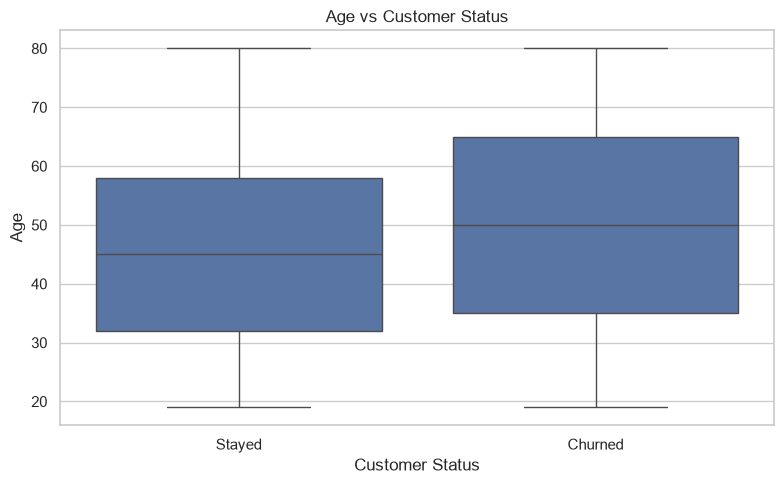

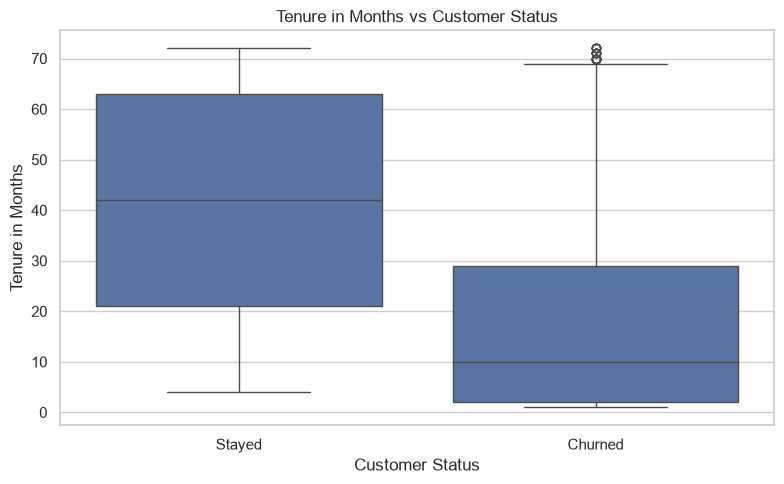

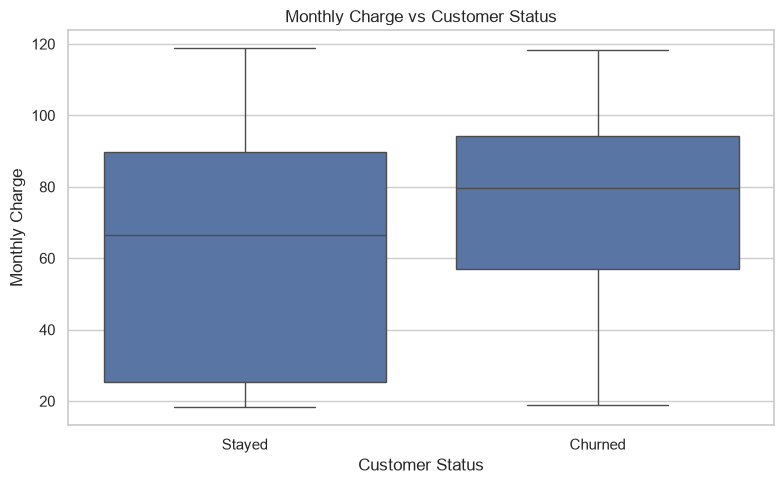

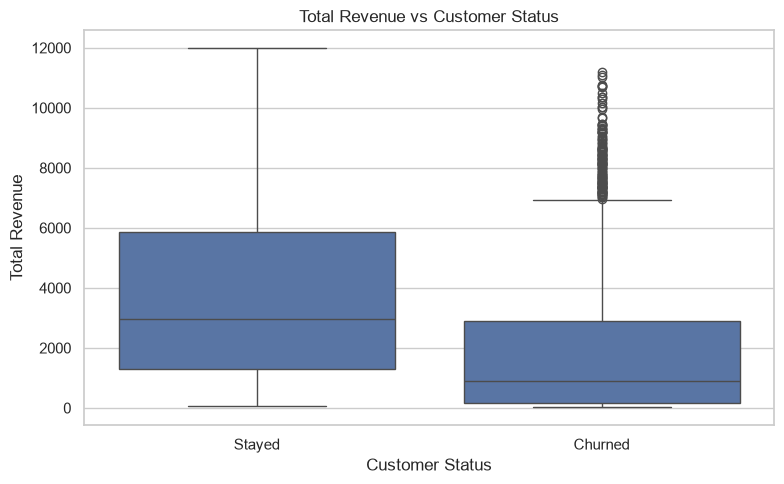

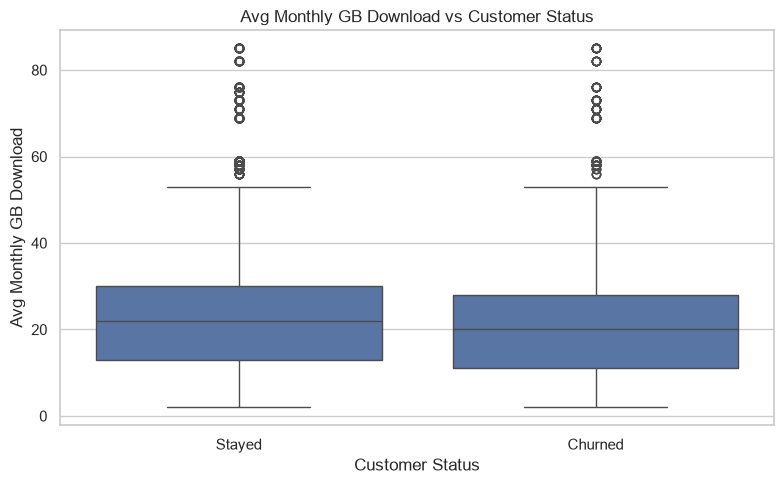

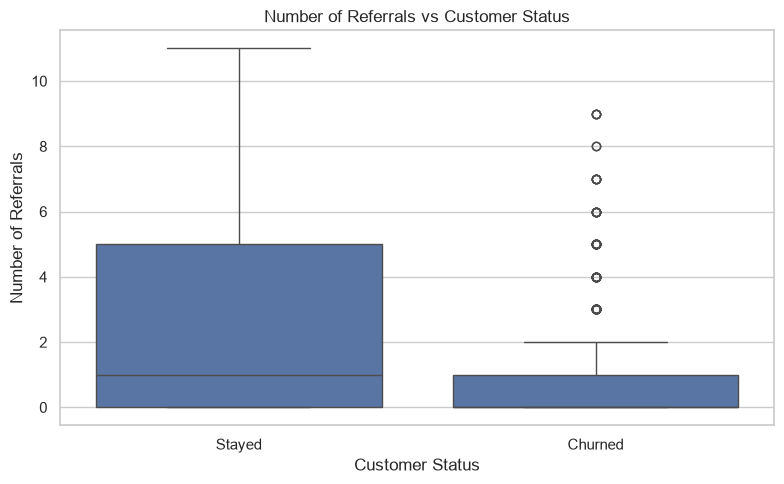

In [97]:
# Boxplots for numerical variables by churn status

for variable in numerical_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Customer Status",
        y=variable
    )

    plt.title(f"{variable} vs Customer Status")
    plt.xlabel("Customer Status")
    plt.ylabel(variable)
    plt.tight_layout()
    plt.show()

### Mann-Whitney U test

In [98]:
mann_whitney_results = []

for column in numerical_features:
    
    churned_values = df.loc[
        df["Churn Flag"] == 1, column
    ].dropna()
    
    stayed_values = df.loc[
        df["Churn Flag"] == 0, column
    ].dropna()
    
    statistic, p_value = stats.mannwhitneyu(
        churned_values,
        stayed_values,
        alternative="two-sided"
    )
    
    mann_whitney_results.append({
        "feature": column,
        "U_statistic": statistic,
        "p_value": p_value
    })

mann_whitney_results = pd.DataFrame(
    mann_whitney_results
)

mann_whitney_results["significant"] = (
    mann_whitney_results["p_value"] < 0.05
)

mann_whitney_results.sort_values("p_value")

,feature,U_statistic,p_value,significant
1,Tenure in Months,1809954.00,0.00,True
3,Total Revenue,2441756.50,0.00,True
5,Number of Referrals,3017018.50,0.00,True
2,Monthly Charge,5151973.50,0.00,True
0,Age,5009465.00,0.00,True
4,Avg Monthly GB Download,2738674.00,0.00,True


### Effect Size — Cramér's V

In [99]:
def cramers_v(confusion_matrix):
    
    chi2 = stats.chi2_contingency(
        confusion_matrix
    )[0]
    
    n = confusion_matrix.sum().sum()
    
    phi2 = chi2 / n
    
    r, k = confusion_matrix.shape
    
    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )
    
    rcorr = r - (
        (r - 1) ** 2 / (n - 1)
    )
    
    kcorr = k - (
        (k - 1) ** 2 / (n - 1)
    )
    
    return np.sqrt(
        phi2corr /
        min((kcorr - 1), (rcorr - 1))
    )

In [100]:
categorical_features = [
    "Gender",
    "Married",
    "Contract",
    "Offer",
    "Internet Service",
    "Internet Type",
    "Payment Method"
]

cramers_results = []

for column in categorical_features:
    
    table = pd.crosstab(
        df[column],
        df["Churn Flag"]
    )
    
    value = cramers_v(table.values)
    
    cramers_results.append({
        "feature": column,
        "cramers_v": value
    })

cramers_results = (
    pd.DataFrame(cramers_results)
    .sort_values("cramers_v", ascending=False)
)

cramers_results

,feature,cramers_v
2,Contract,0.51
3,Offer,0.49
4,Internet Service,0.22
6,Payment Method,0.22
5,Internet Type,0.21
1,Married,0.18
0,Gender,0.00


### Correlation Analysis

In [101]:
correlation_features = [
    "Age",
    "Number of Dependents",
    "Number of Referrals",
    "Tenure in Months",
    "Avg Monthly Long Distance Charges",
    "Avg Monthly GB Download",
    "Monthly Charge",
    "Total Charges",
    "Total Refunds",
    "Total Extra Data Charges",
    "Total Long Distance Charges",
    "Total Revenue",
    "Churn Flag"
]

correlation_matrix = (
    df[correlation_features]
    .corr()
    .round(2)
)

correlation_matrix

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Churn Flag
Age,1.00,-0.13,-0.03,-0.01,-0.02,-0.57,0.14,0.05,0.02,0.02,-0.01,0.04,0.11
Number of Dependents,-0.13,1.00,0.28,0.11,-0.01,0.30,-0.14,0.02,0.01,-0.02,0.07,0.03,-0.23
Number of Referrals,-0.03,0.28,1.00,0.32,-0.00,0.08,0.01,0.24,0.02,-0.00,0.21,0.25,-0.31
Tenure in Months,-0.01,0.11,0.32,1.00,0.01,0.04,0.20,0.81,0.04,0.07,0.65,0.84,-0.43
Avg Monthly Long Distance Charges,-0.02,-0.01,-0.00,0.01,1.00,0.01,0.02,0.01,-0.03,0.02,0.58,0.18,-0.00
Avg Monthly GB Download,-0.57,0.30,0.08,0.04,0.01,1.00,-0.02,0.03,-0.01,0.01,0.02,0.03,-0.10
Monthly Charge,0.14,-0.14,0.01,0.20,0.02,-0.02,1.00,0.65,0.02,0.12,0.22,0.58,0.18
Total Charges,0.05,0.02,0.24,0.81,0.01,0.03,0.65,1.00,0.03,0.11,0.59,0.97,-0.25
Total Refunds,0.02,0.01,0.02,0.04,-0.03,-0.01,0.02,0.03,1.00,0.01,0.02,0.02,-0.04
Total Extra Data Charges,0.02,-0.02,-0.00,0.07,0.02,0.01,0.12,0.11,0.01,1.00,0.05,0.11,-0.00


### Churn correlation

In [102]:
churn_correlations = (
    correlation_matrix["Churn Flag"]
    .drop("Churn Flag")
    .sort_values()
)

churn_correlations

Tenure in Months                    -0.43
Number of Referrals                 -0.31
Total Revenue                       -0.28
Total Long Distance Charges         -0.27
Total Charges                       -0.25
Number of Dependents                -0.23
Avg Monthly GB Download             -0.10
Total Refunds                       -0.04
Avg Monthly Long Distance Charges   -0.00
Total Extra Data Charges            -0.00
Age                                  0.11
Monthly Charge                       0.18
Name: Churn Flag, dtype: float64

## Summary of Findings

- **Overall churn rate is 28%** (1,869 of 6,589 customers) — more than 1 in 4 customers left.
- **Contract type is the strongest driver of churn.** Month-to-month customers churn at **52%**, vs **11%** for one-year and just **3%** for two-year contracts.
- **Churn is concentrated early in the customer lifecycle.** Average tenure is **18 months** for churned customers vs **41 months** for retained ones, and **77%** of customers who churn do so within their first 6 months.
- **Fiber optic customers churn the most (42%)** despite paying the highest average monthly charge (~$92) — a possible price/value or service quality mismatch.
- **Churned customers bring in far less revenue and have fewer referrals** ($1,971 vs $3,736 avg. revenue; 0.52 vs 2.61 avg. referrals), pointing to weaker engagement before they leave.
- **Nearly half of stated churn reasons (45%) point to competitors** — better devices, offers, or data/speed plans.
- **The highest-risk profile — new, month-to-month, fiber-optic customers — churns at over 80%** and should be the top priority for retention efforts.
- **Demographics (gender, age) show little to no meaningful link to churn** — contract, tenure, and offer type matter far more and should guide segmentation.

**Bottom line:** churn is driven mainly by contract flexibility and early-tenure risk, not by who the customer is. Retention efforts should focus on the first 6 months and on converting month-to-month, fiber-optic customers to longer-term contracts.